Machine Learning Classification Project Guide

Project Title: Online Exam Cheating Risk Detection System

* Introduction


With the growing adoption of online examinations across educational institutions and EdTech platforms,
maintaining academic integrity has become a major concern. Students may engage in various forms of unfair
practices such as switching browser tabs, disabling monitoring systems, device switching, or attempting
copy-paste actions during online assessments

This project aims to develop a Machine Learning classification model that predicts the likelihood of cheating
behavior based on structured examination activity logs and interaction patterns captured during the assessment.

* Data Dictionary

Feature Name Description
exam_duration_minutes Total duration of the examination
time_taken_to_start Delay in starting the exam
tab_switch_count Number of browser tab switches
fullscreen_exit_count Fullscreen exit attempts
copy_paste_attempts Copy paste attempts during exam
device_switch_count Device switching count
ip_address_change IP address change indicator
mouse_movement_speed Average cursor movement speed
inactivity_time Idle time during exam
question_skip_count Number of questions skipped
revisits_count Revisited questions
login_attempts Number of login retries
network_instability Connection drop frequency
webcam_disabled_flag Webcam disabled status
background_noise_flag Background noise detected
exam_time_remaining Remaining exam time
typing_speed Typing speed
answer_change_count Number of answer edits
suspicious_activity_score Combined behavioral risk score
cheating_risk Target variable indicating cheating risk

* Project Workflow


EDA Steps


Step 1: Data Understanding

In [2]:
pip install pandas

In [17]:
import pandas as pd

In [18]:
df=pd.read_csv("Downloads/online_exam_cheating_risk_dataset.csv")

Perform an initial overview of the dataset using head(), info(), and describe() methods to understand the structure,
data types, and summary statistics

In [5]:
df.head()

,exam_duration_minutes,time_taken_to_start,tab_switch_count,fullscreen_exit_count,copy_paste_attempts,device_switch_count,ip_address_change,mouse_movement_speed,inactivity_time,question_skip_count,revisits_count,login_attempts,network_instability,webcam_disabled_flag,background_noise_flag,exam_time_remaining,typing_speed,answer_change_count,suspicious_activity_score,cheating_risk
0,60,3,3,1,1,0,0,595,138,4,19,4,0,0,0,25,41,1,9,1
1,86,4,5,0,0,0,0,554,102,6,8,4,2,0,0,18,41,11,9,1
2,58,8,3,1,0,1,0,703,125,5,16,1,1,0,0,27,37,11,6,1
3,40,0,5,1,3,0,0,390,82,1,0,2,0,0,0,25,36,7,11,0
4,36,9,5,2,1,1,0,686,224,8,23,4,0,1,1,14,41,14,13,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   exam_duration_minutes      12000 non-null  int64
 1   time_taken_to_start        12000 non-null  int64
 2   tab_switch_count           12000 non-null  int64
 3   fullscreen_exit_count      12000 non-null  int64
 4   copy_paste_attempts        12000 non-null  int64
 5   device_switch_count        12000 non-null  int64
 6   ip_address_change          12000 non-null  int64
 7   mouse_movement_speed       12000 non-null  int64
 8   inactivity_time            12000 non-null  int64
 9   question_skip_count        12000 non-null  int64
 10  revisits_count             12000 non-null  int64
 11  login_attempts             12000 non-null  int64
 12  network_instability        12000 non-null  int64
 13  webcam_disabled_flag       12000 non-null  int64
 14  background_noise_flag 

In [7]:
df.describe()

,exam_duration_minutes,time_taken_to_start,tab_switch_count,fullscreen_exit_count,copy_paste_attempts,device_switch_count,ip_address_change,mouse_movement_speed,inactivity_time,question_skip_count,revisits_count,login_attempts,network_instability,webcam_disabled_flag,background_noise_flag,exam_time_remaining,typing_speed,answer_change_count,suspicious_activity_score,cheating_risk
count,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000
mean,61.704833,3.41825,4.435167,1.424833,0.653750,0.258583,0.086833,529.420583,90.94550,4.180917,13.747000,1.690083,0.780083,0.124167,0.168917,15.826667,40.32200,9.361000,8.462417,0.500000
std,24.498869,2.54536,2.193102,1.247055,0.785013,0.524475,0.281602,99.738964,39.98765,3.817294,9.830101,1.017655,0.962703,0.329785,0.374694,9.664345,6.24471,7.239041,3.079076,0.500021
min,30.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,173.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,19.00000,0.000000,1.000000,0.000000
25%,41.000000,1.00000,3.000000,0.000000,0.000000,0.000000,0.000000,461.000000,62.00000,1.000000,6.000000,1.000000,0.000000,0.000000,0.000000,9.000000,36.00000,3.000000,6.000000,0.000000
50%,60.000000,3.00000,4.000000,1.000000,0.000000,0.000000,0.000000,527.000000,87.00000,4.000000,13.000000,1.000000,1.000000,0.000000,0.000000,16.000000,40.00000,9.000000,8.000000,0.500000
75%,79.000000,5.00000,6.000000,2.000000,1.000000,0.000000,0.000000,595.000000,115.00000,7.000000,20.000000,2.000000,1.000000,0.000000,0.000000,22.000000,45.00000,14.000000,10.000000,1.000000
max,171.000000,13.00000,13.000000,6.000000,5.000000,4.000000,1.000000,950.000000,302.00000,22.000000,60.000000,8.000000,6.000000,1.000000,1.000000,57.000000,62.00000,42.000000,23.000000,1.000000


Step 2: Univariate Analysis

Analyze each feature individually using appropriate plots (histograms, bar charts, box plots) and summary
statistics. Identify distributions, outliers, and unusual patterns

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

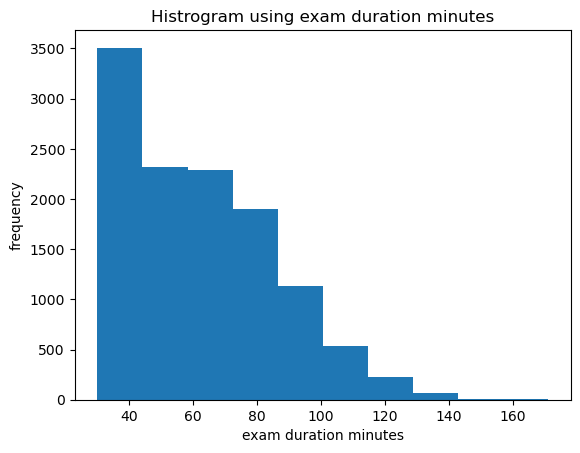

In [9]:
plt.hist(df["exam_duration_minutes"])
plt.title("Histrogram using exam duration minutes")
plt.xlabel("exam duration minutes")
plt.ylabel("frequency")
plt.show()

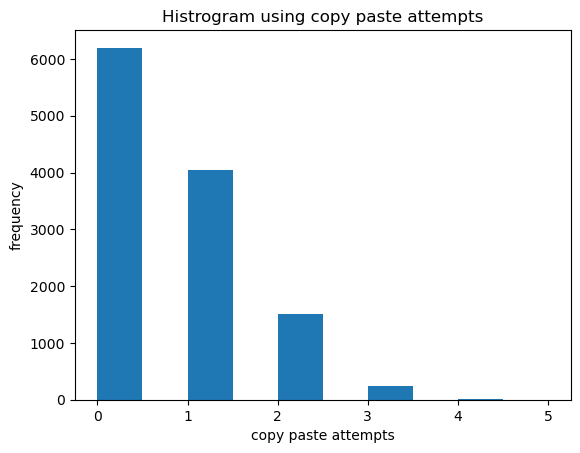

In [10]:
plt.hist(df["copy_paste_attempts"])
plt.title("Histrogram using copy paste attempts")
plt.xlabel("copy paste attempts")
plt.ylabel("frequency")
plt.show()

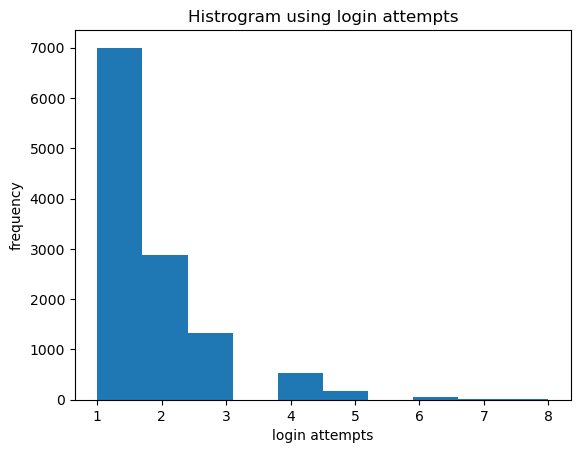

In [11]:
plt.hist(df["login_attempts"])
plt.title("Histrogram using login attempts")
plt.xlabel("login attempts")
plt.ylabel("frequency")
plt.show()

Step 3: Bivariate Analysis

Perform feature-to-feature analysis across all meaningful pairs. Use scatter plots, grouped aggregations, and
comparative plots to understand relationships and dependencies between variables

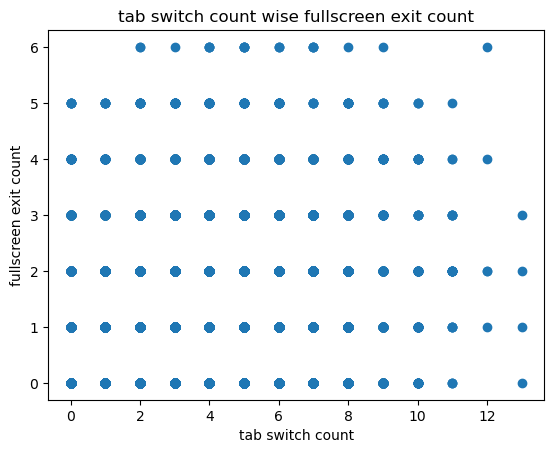

In [12]:
plt.scatter(df["tab_switch_count"],df["fullscreen_exit_count"])
plt.title("tab switch count wise fullscreen exit count")
plt.xlabel("tab switch count")
plt.ylabel("fullscreen exit count")
plt.show()

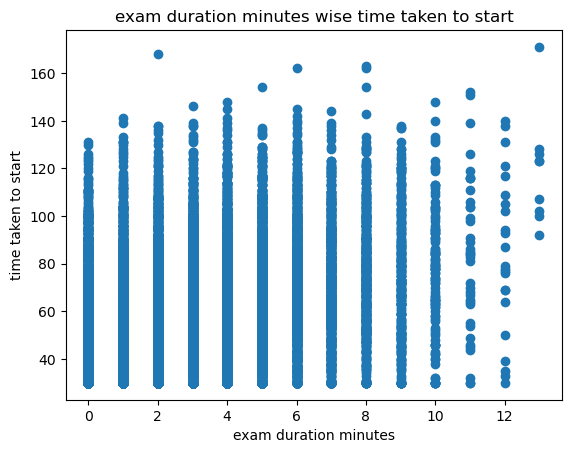

In [13]:
plt.scatter(df["time_taken_to_start"],df["exam_duration_minutes"])
plt.title("exam duration minutes wise time taken to start")
plt.xlabel("exam duration minutes")
plt.ylabel("time taken to start")
plt.show()

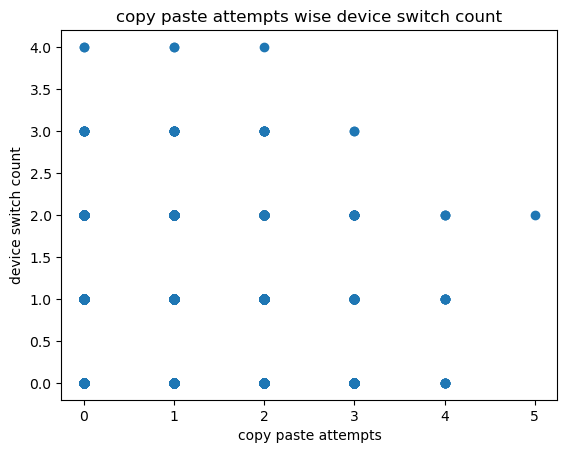

In [14]:
plt.scatter(df["copy_paste_attempts"],df["device_switch_count"])
plt.title("copy paste attempts wise device switch count")
plt.xlabel("copy paste attempts")
plt.ylabel("device switch count")
plt.show()


Step 4: Target Relationship Analysis

Evaluate how each feature relates to the target variable using suitable visualizations and grouped statistics.
Repeat this for every feature

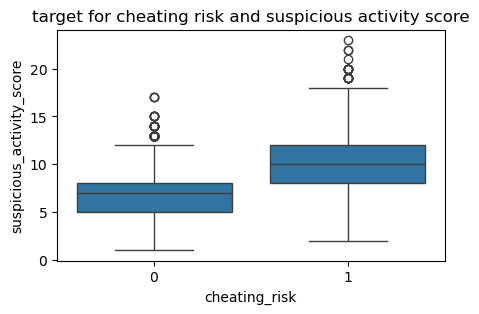

In [15]:
plt.figure(figsize=(5,3))
sns.boxplot(x="cheating_risk",y="suspicious_activity_score",data=df)
plt.title("target for cheating risk and suspicious activity score")
plt.show()

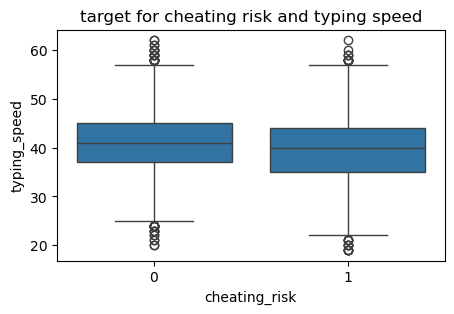

In [16]:
plt.figure(figsize=(5,3))
sns.boxplot(x="cheating_risk",y="typing_speed",data=df)
plt.title("target for cheating risk and typing speed")
plt.show()

Step 5: Multivariate Analysis

Use correlation heatmaps and other multivariate techniques to identify the strongest combined relationships
among features.

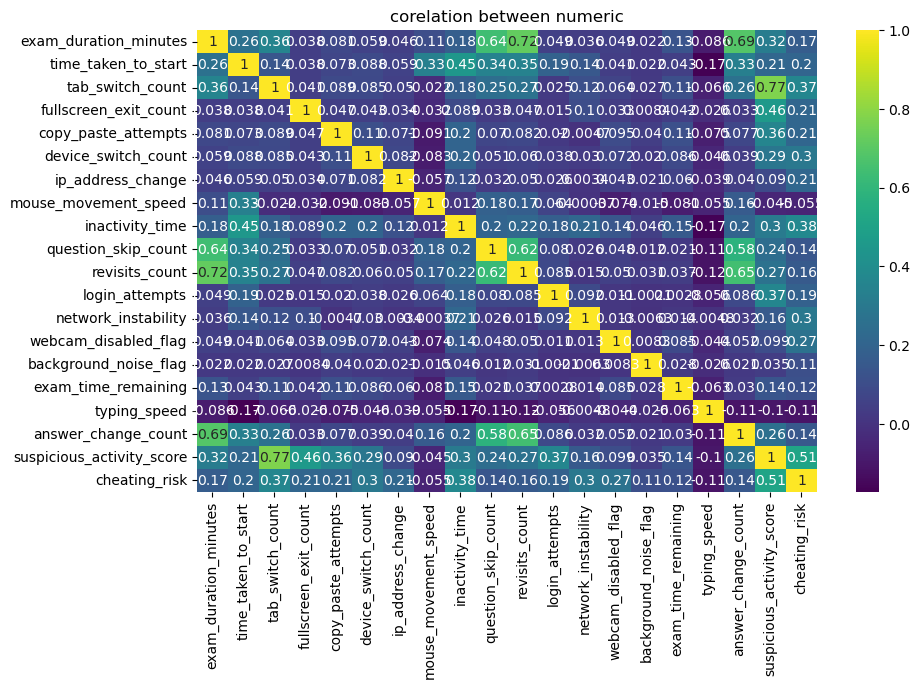

In [74]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True, cmap="viridis")
plt.title("corelation between numeric")
plt.show()

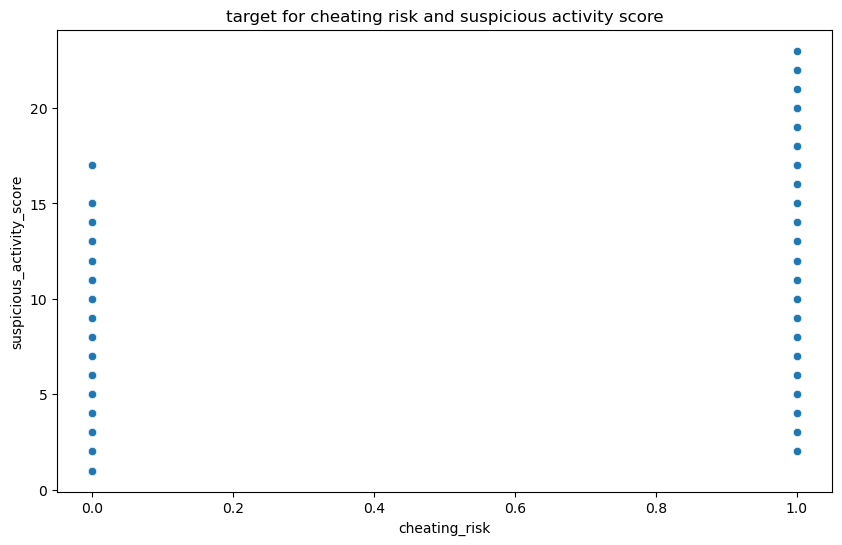

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="cheating_risk",y="suspicious_activity_score",data=df)
plt.title("target for cheating risk and suspicious activity score")
plt.show()

Step 6: Data Preprocessing

Handle missing values, encode categorical/binary variables where required, and scale numerical features if
needed.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   exam_duration_minutes      12000 non-null  int64
 1   time_taken_to_start        12000 non-null  int64
 2   tab_switch_count           12000 non-null  int64
 3   fullscreen_exit_count      12000 non-null  int64
 4   copy_paste_attempts        12000 non-null  int64
 5   device_switch_count        12000 non-null  int64
 6   ip_address_change          12000 non-null  int64
 7   mouse_movement_speed       12000 non-null  int64
 8   inactivity_time            12000 non-null  int64
 9   question_skip_count        12000 non-null  int64
 10  revisits_count             12000 non-null  int64
 11  login_attempts             12000 non-null  int64
 12  network_instability        12000 non-null  int64
 13  webcam_disabled_flag       12000 non-null  int64
 14  background_noise_flag 

In [20]:
df.isnull().sum()

exam_duration_minutes        0
time_taken_to_start          0
tab_switch_count             0
fullscreen_exit_count        0
copy_paste_attempts          0
device_switch_count          0
ip_address_change            0
mouse_movement_speed         0
inactivity_time              0
question_skip_count          0
revisits_count               0
login_attempts               0
network_instability          0
webcam_disabled_flag         0
background_noise_flag        0
exam_time_remaining          0
typing_speed                 0
answer_change_count          0
suspicious_activity_score    0
cheating_risk                0
dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder
cr=df["cheating_risk"]
encoder=LabelEncoder()
cr_encoded=encoder.fit_transform(cr)
print(cr_encoded)
print("Mapping",dict(zip(encoder.classes_,range(len(encoder.classes_)))))

[1 1 1 ... 0 1 1]
Mapping {np.int64(0): 0, np.int64(1): 1}


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   exam_duration_minutes      12000 non-null  int64
 1   time_taken_to_start        12000 non-null  int64
 2   tab_switch_count           12000 non-null  int64
 3   fullscreen_exit_count      12000 non-null  int64
 4   copy_paste_attempts        12000 non-null  int64
 5   device_switch_count        12000 non-null  int64
 6   ip_address_change          12000 non-null  int64
 7   mouse_movement_speed       12000 non-null  int64
 8   inactivity_time            12000 non-null  int64
 9   question_skip_count        12000 non-null  int64
 10  revisits_count             12000 non-null  int64
 11  login_attempts             12000 non-null  int64
 12  network_instability        12000 non-null  int64
 13  webcam_disabled_flag       12000 non-null  int64
 14  background_noise_flag 

Step 7: Feature Engineering

Create new meaningful features based on domain understanding (example: combining multiple activity indicators
into a single score).

In [23]:
df["behavioral_risk_score"] = (
    df["tab_switch_count"] +
    df["fullscreen_exit_count"] +
    df["copy_paste_attempts"] +
    df["device_switch_count"] +
    df["ip_address_change"]
)

In [24]:
df.isnull().sum()

exam_duration_minutes        0
time_taken_to_start          0
tab_switch_count             0
fullscreen_exit_count        0
copy_paste_attempts          0
device_switch_count          0
ip_address_change            0
mouse_movement_speed         0
inactivity_time              0
question_skip_count          0
revisits_count               0
login_attempts               0
network_instability          0
webcam_disabled_flag         0
background_noise_flag        0
exam_time_remaining          0
typing_speed                 0
answer_change_count          0
suspicious_activity_score    0
cheating_risk                0
behavioral_risk_score        0
dtype: int64

In [25]:
df.head()

,exam_duration_minutes,time_taken_to_start,tab_switch_count,fullscreen_exit_count,copy_paste_attempts,device_switch_count,ip_address_change,mouse_movement_speed,inactivity_time,question_skip_count,...,login_attempts,network_instability,webcam_disabled_flag,background_noise_flag,exam_time_remaining,typing_speed,answer_change_count,suspicious_activity_score,cheating_risk,behavioral_risk_score
0,60,3,3,1,1,0,0,595,138,4,...,4,0,0,0,25,41,1,9,1,5
1,86,4,5,0,0,0,0,554,102,6,...,4,2,0,0,18,41,11,9,1,5
2,58,8,3,1,0,1,0,703,125,5,...,1,1,0,0,27,37,11,6,1,5
3,40,0,5,1,3,0,0,390,82,1,...,2,0,0,0,25,36,7,11,0,9
4,36,9,5,2,1,1,0,686,224,8,...,4,0,1,1,14,41,14,13,1,9


Step 8: Train-Test Split

Split the dataset into training and testing sets using stratified sampling.

In [19]:
from sklearn.model_selection import train_test_split
X = df.drop(["cheating_risk"], axis=1)  
y = df["cheating_risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Cheating Risk in train:", y_train.value_counts(normalize=True))
print("Cheating Risk in test:", y_test.value_counts(normalize=True))

Training set size: (9600, 19)
Test set size: (2400, 19)
Cheating Risk in train: cheating_risk
0    0.5
1    0.5
Name: proportion, dtype: float64
Cheating Risk in test: cheating_risk
0    0.5
1    0.5
Name: proportion, dtype: float64


In [20]:
print(y_test.isnull().sum())

0


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 9: Model Building

Train and compare multiple classification models such as Logistic Regression, Decision Tree, Random Forest,
Gradient Boosting, XGBoost, and KNN.

Step 10: Model Evaluation

Evaluate models using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, and Confusion Matrix. Compare
results and select the best-performing model

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,ConfusionMatrixDisplay,accuracy_score
from sklearn.model_selection import train_test_split
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

In [23]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.8245833333333333


In [19]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.81      0.85      0.83      1200
           1       0.84      0.80      0.82      1200

    accuracy                           0.82      2400
   macro avg       0.83      0.82      0.82      2400
weighted avg       0.83      0.82      0.82      2400



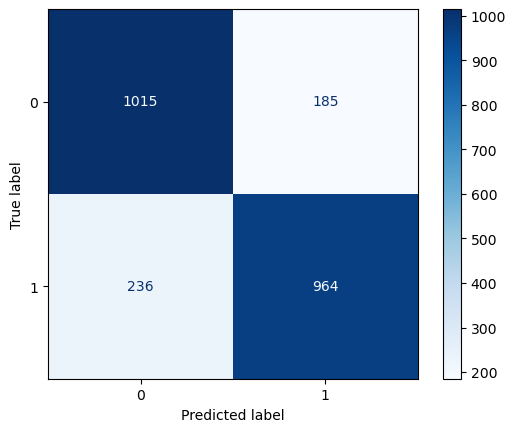

In [26]:
ConfusionMatrixDisplay.from_estimator(log_reg,X_test,y_test,cmap="Blues")
plt.show()

In [24]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.9058791666666668


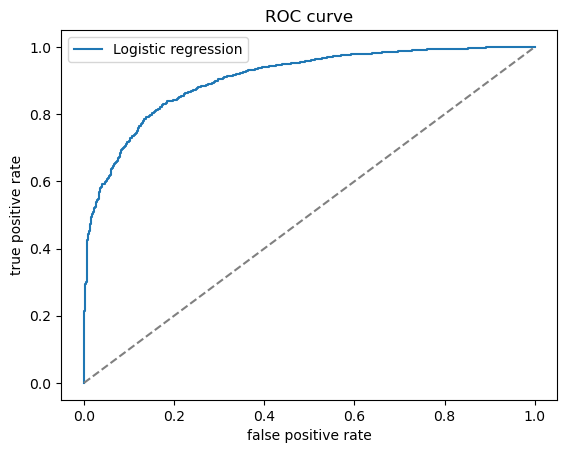

In [25]:
from sklearn.metrics import roc_curve
fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="Logistic regression")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

dec_cla =  DecisionTreeClassifier(random_state=42)

dec_cla.fit(X_train, y_train)

y_pred = dec_cla.predict(X_test)
y_prob = dec_cla.predict_proba(X_test)[:, 1] 

In [28]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.73


In [29]:
print("Classification Report:\n",classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73      1200
           1       0.73      0.73      0.73      1200

    accuracy                           0.73      2400
   macro avg       0.73      0.73      0.73      2400
weighted avg       0.73      0.73      0.73      2400



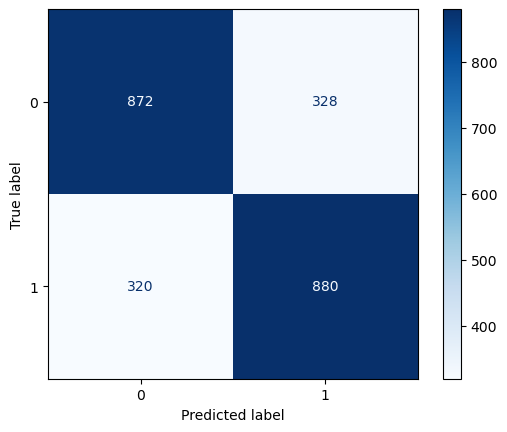

In [34]:
ConfusionMatrixDisplay.from_estimator(dec_cla, X_test, y_test,cmap="Blues")
plt.show()

In [35]:
print("Roc-Auc Score",roc_auc_score(y_test,y_prob))

Roc-Auc Score 0.73


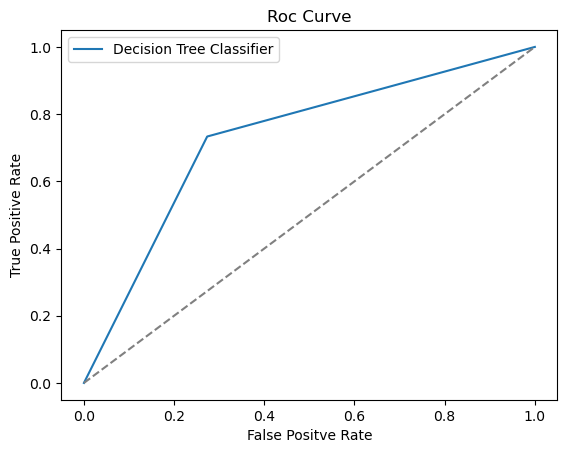

In [36]:
from sklearn.metrics import roc_curve
fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="Decision Tree Classifier")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positve Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc Curve")
plt.legend()
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,accuracy_score
rf= RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [38]:
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.8045833333333333


In [39]:
print("Classification Report:\n",classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.81      1200
           1       0.81      0.80      0.80      1200

    accuracy                           0.80      2400
   macro avg       0.80      0.80      0.80      2400
weighted avg       0.80      0.80      0.80      2400



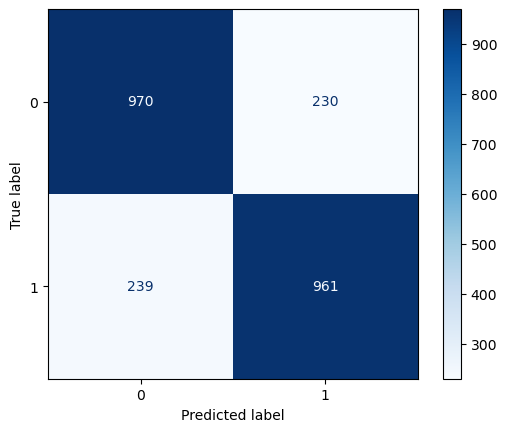

In [40]:
ConfusionMatrixDisplay.from_estimator(rf,X_test,y_test,cmap="Blues")
plt.show()

In [41]:
print("Roc-Auc Score",roc_auc_score(y_test,y_prob))

Roc-Auc Score 0.8909798611111112


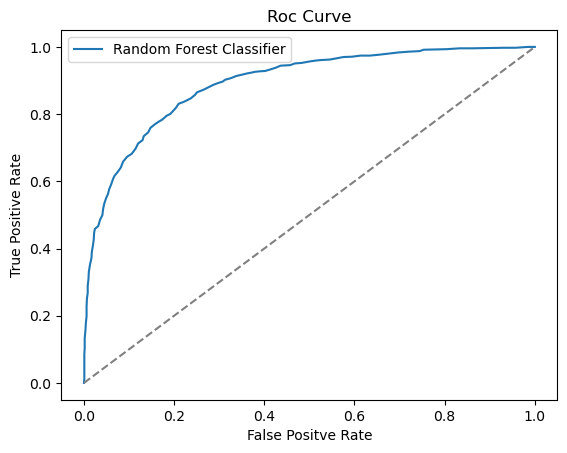

In [42]:
from sklearn.metrics import roc_curve
fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="Random Forest Classifier")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positve Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc Curve")
plt.legend()
plt.show()

In [45]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
gra_bo_cla = GradientBoostingClassifier(random_state=42)
gra_bo_cla.fit(X_train, y_train)
y_pred = gra_bo_cla.predict(X_test)
y_prob = gra_bo_cla.predict_proba(X_test)[:, 1] 

In [46]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8191666666666667


In [47]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.82      0.82      0.82      1200
           1       0.82      0.81      0.82      1200

    accuracy                           0.82      2400
   macro avg       0.82      0.82      0.82      2400
weighted avg       0.82      0.82      0.82      2400



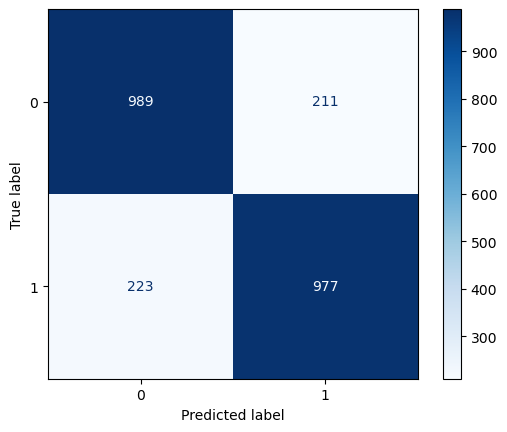

In [49]:
ConfusionMatrixDisplay.from_estimator(gra_bo_cla,X_test,y_test,cmap="Blues")
plt.show()

In [50]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.901911111111111


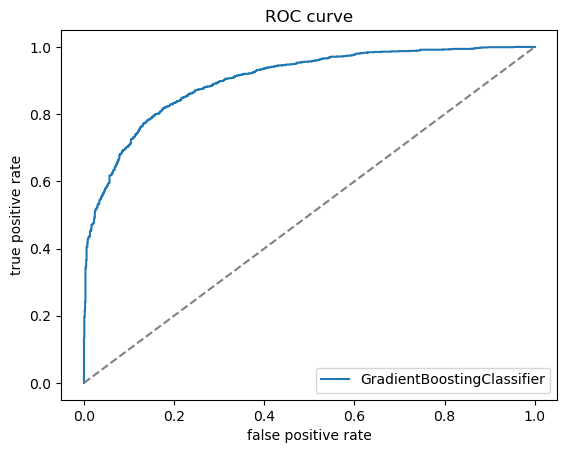

In [51]:
from sklearn.metrics import roc_curve
fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="GradientBoostingClassifier")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [36]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,accuracy_score
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_prob =xgb.predict_proba(X_test)[:,1] 

In [60]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8020833333333334


In [61]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.79      0.82      0.81      1200
           1       0.81      0.78      0.80      1200

    accuracy                           0.80      2400
   macro avg       0.80      0.80      0.80      2400
weighted avg       0.80      0.80      0.80      2400



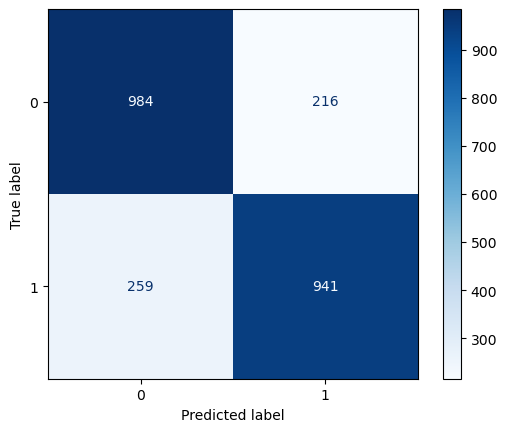

In [64]:
ConfusionMatrixDisplay.from_estimator(xgb_clf,X_test,y_test,cmap="Blues")
plt.show()

In [65]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8874166666666667


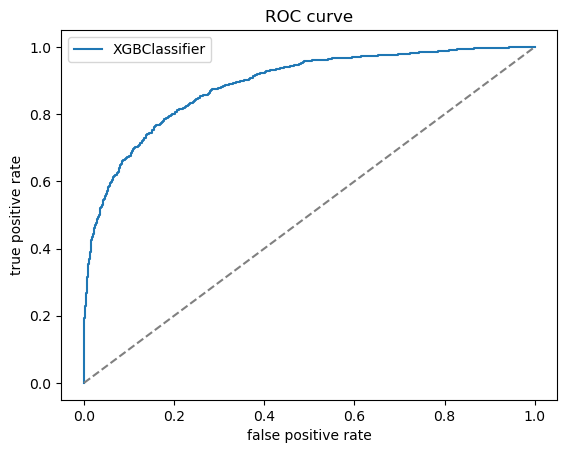

In [66]:
from sklearn.metrics import roc_curve
fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="XGBClassifier")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [67]:
#KNN classifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
KNNCla = KNeighborsClassifier()
KNNCla.fit(X_train, y_train)
y_pred = KNNCla.predict(X_test)
y_prob = KNNCla.predict_proba(X_test)[:, 1] 

In [68]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.78


In [69]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.76      0.82      0.79      1200
           1       0.80      0.74      0.77      1200

    accuracy                           0.78      2400
   macro avg       0.78      0.78      0.78      2400
weighted avg       0.78      0.78      0.78      2400



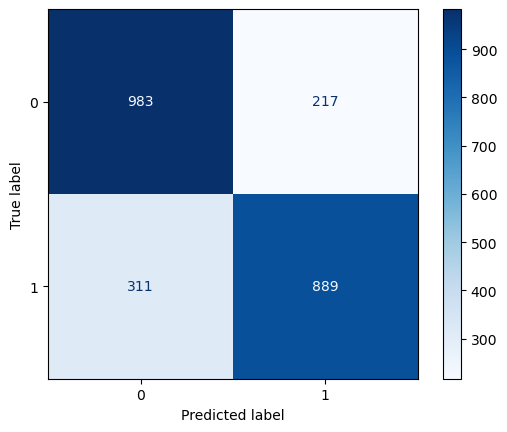

In [71]:
ConfusionMatrixDisplay.from_estimator(KNNCla,X_test,y_test,cmap="Blues")
plt.show()

In [72]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8476833333333333


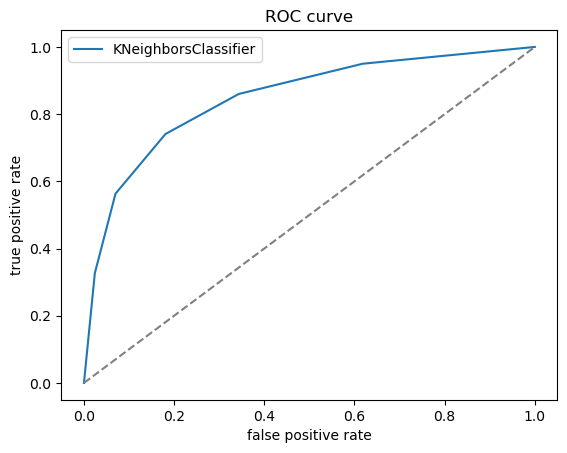

In [73]:
from sklearn.metrics import roc_curve
fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="KNeighborsClassifier")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()